## Randon Forest - Decision Tree Classification and Regression

In [55]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import pandas as pd

df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


<Axes: xlabel='AHD', ylabel='count'>

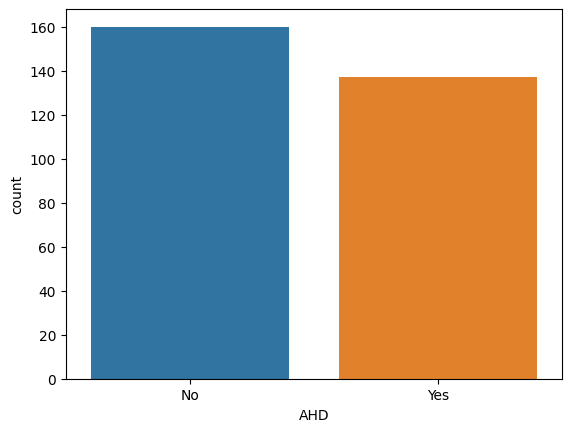

In [57]:
df.dropna(inplace=True) #drop any null values to clean data set

sns.countplot(data=df, x= "AHD", hue= "AHD")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


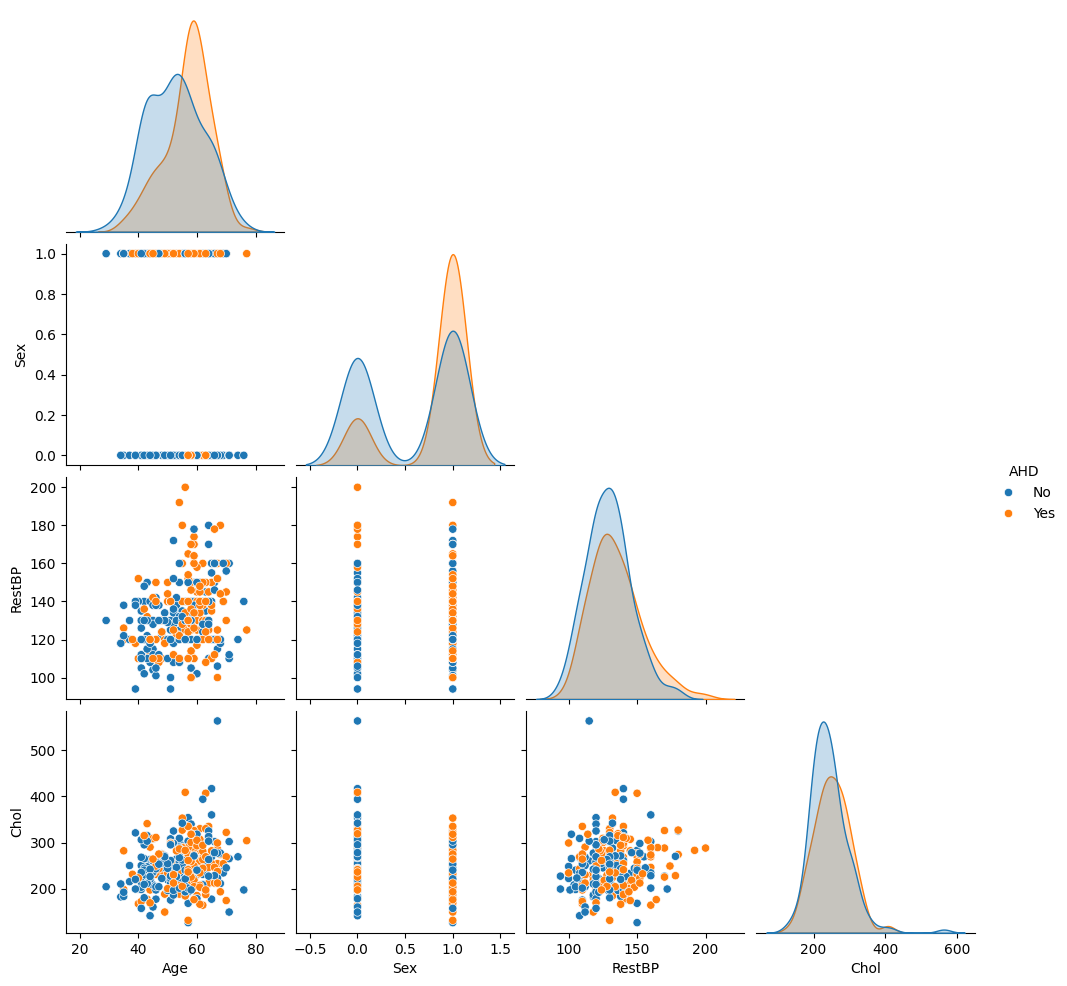

In [22]:
# feature engineering to look at correlations through heat map or pairplot
# Target variable is AHD= Yes/No and its correlation to numerical features
# consider Thal and ChestPain as categorical predictors
# make pairplot to explore

sns.pairplot(
    data = df[["Age", "Sex", "RestBP", "Chol",  "AHD"]],
    corner= True,
    hue= "AHD",
    palette="tab10"
)

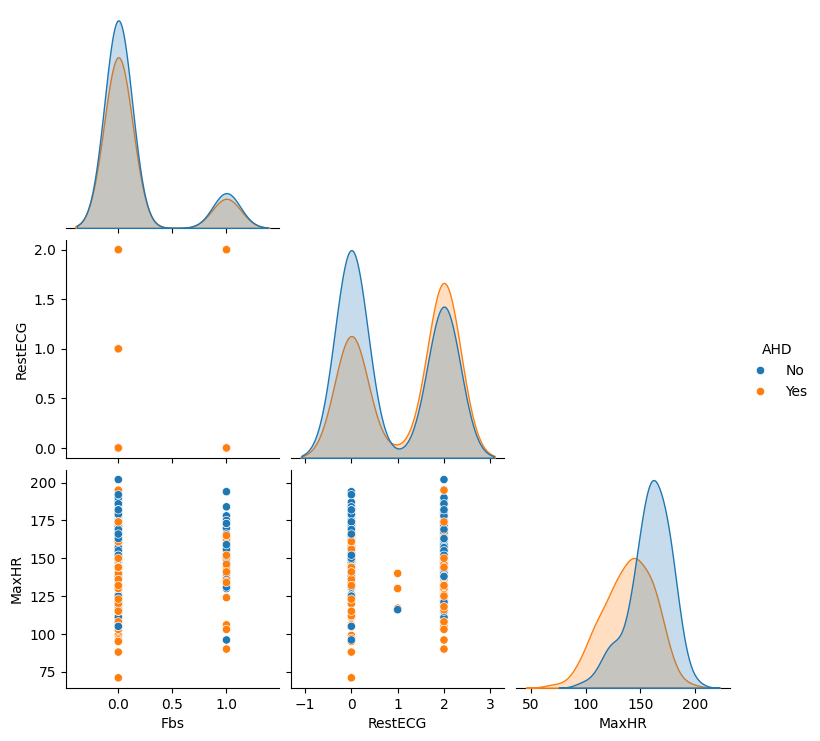

In [20]:
sns.pairplot(
    data=df[["Fbs", "RestECG", "MaxHR","AHD"]],
    corner=True,
    hue="AHD",
    palette="tab10",
)



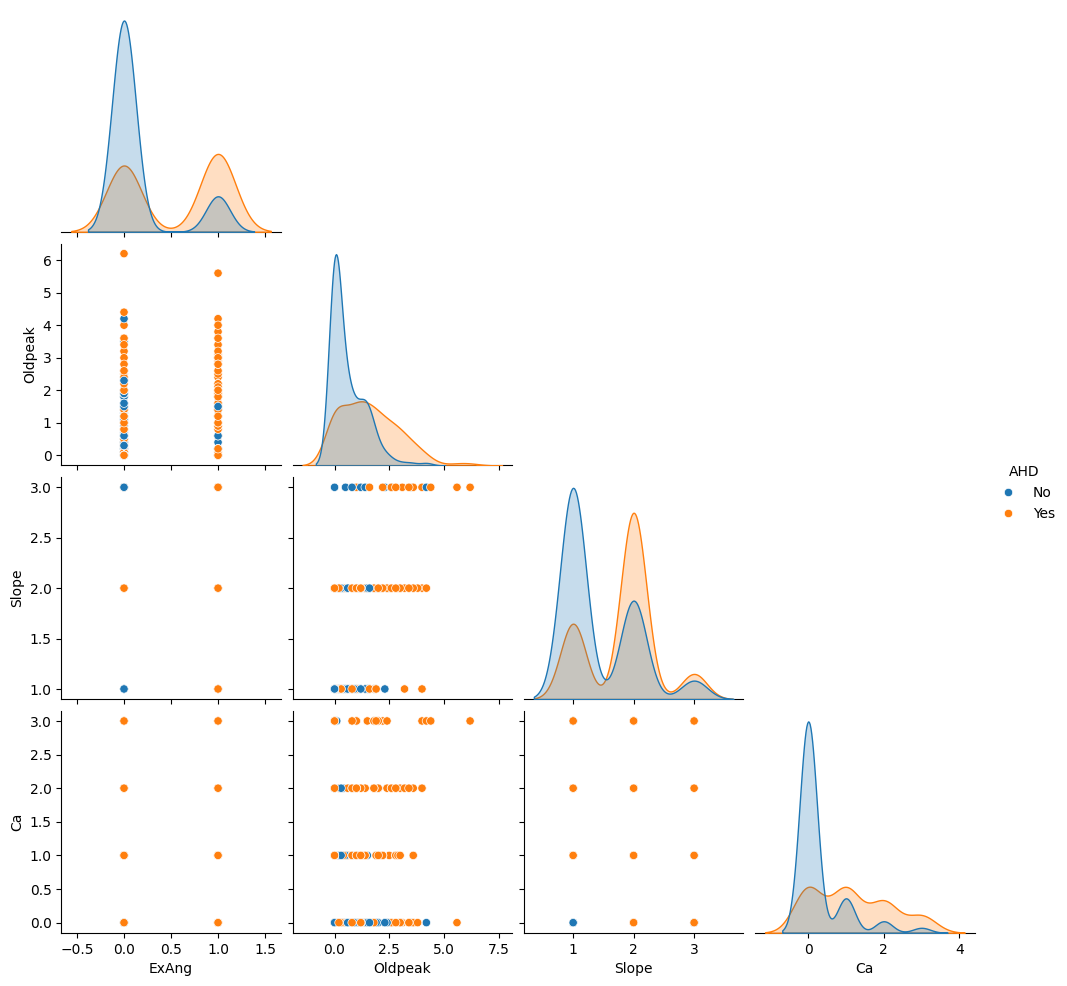

In [21]:
sns.pairplot( 
    data=df[["ExAng", "Oldpeak", "Slope", "Ca", "AHD"]],
    corner=True,
    hue= "AHD",
    palette="tab10"
    )


In [23]:
df.corr

<bound method DataFrame.corr of      Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  \
1     63    1       typical     145   233    1        2    150      0   
2     67    1  asymptomatic     160   286    0        2    108      1   
3     67    1  asymptomatic     120   229    0        2    129      1   
4     37    1    nonanginal     130   250    0        0    187      0   
5     41    0    nontypical     130   204    0        2    172      0   
..   ...  ...           ...     ...   ...  ...      ...    ...    ...   
298   57    0  asymptomatic     140   241    0        0    123      1   
299   45    1       typical     110   264    0        0    132      0   
300   68    1  asymptomatic     144   193    1        0    141      0   
301   57    1  asymptomatic     130   131    0        0    115      1   
302   57    0    nontypical     130   236    0        2    174      0   

     Oldpeak  Slope   Ca        Thal  AHD  
1        2.3      3  0.0       fixed   No  
2  

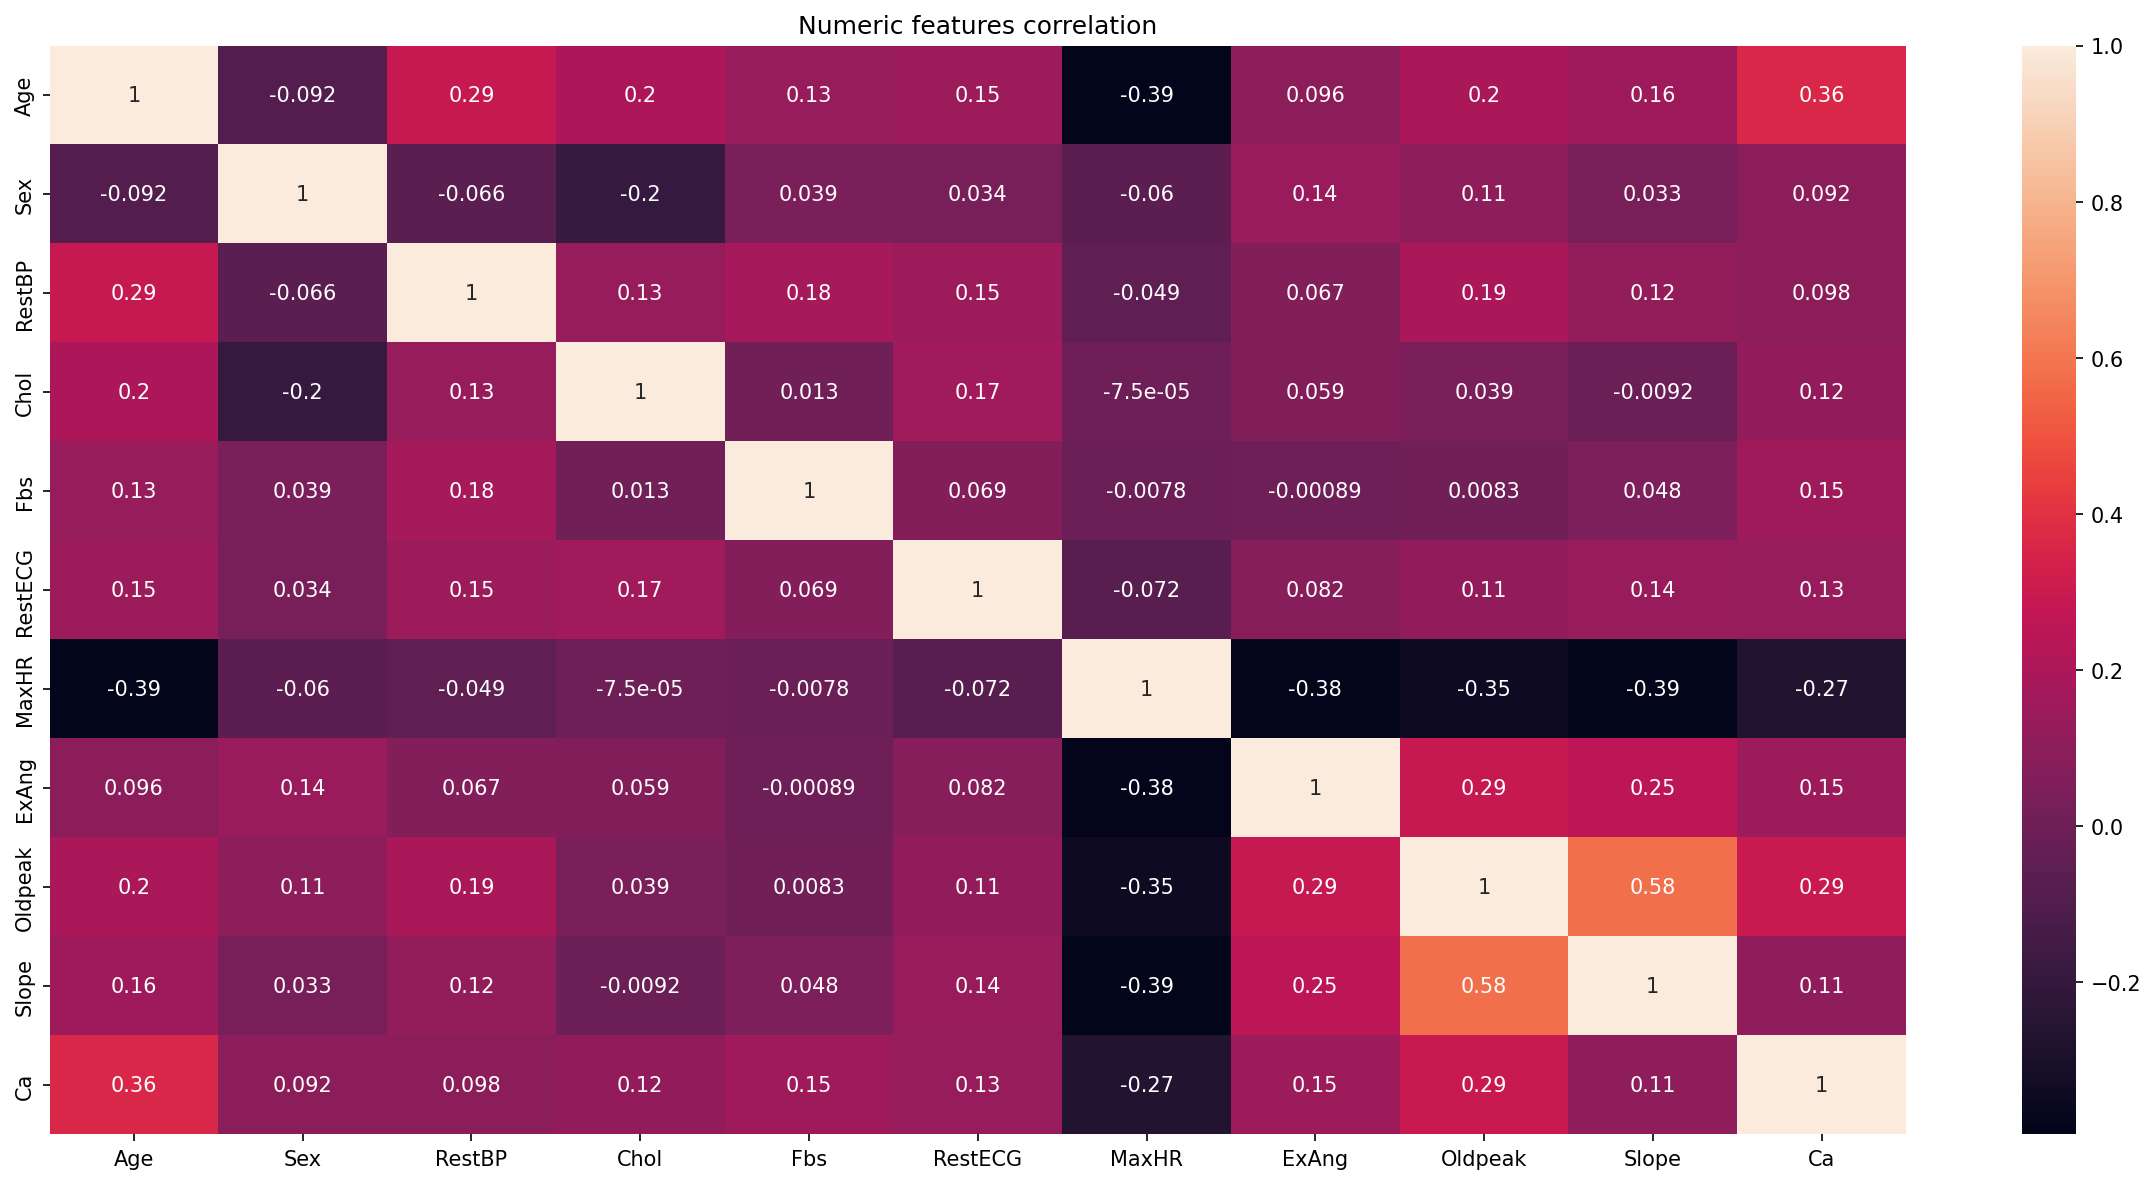

In [27]:
# heatmap
import matplotlib.pyplot as plt
import numpy as np

# first, exclude categorical columns so plot only on numeric
corr = df.corr(numeric_only=True)

fig, ax=plt.subplots(1, figsize=(16, 8), dpi= 150)
sns.heatmap(corr, annot=True, ax=ax)
plt.title("Numeric features correlation")
plt.tight_layout()
plt.show()

In [28]:
#include object dtypes ie Thal, AHD and ChestPain
# AHD is Yes/No so 1/0
df["AHD"] = df["AHD"].map({"Yes": 1, "No":0})
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0


In [29]:
# ChestPain, Thal -> numbers
# dummy encoding -> 1/0
df_dummy = pd.get_dummies(df, columns=["ChestPain", "Thal"], drop_first=True)
df_dummy.head()


,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,63,1,145,233,1,2,150,0,2.3,3,0.0,0,False,False,True,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,1,False,False,False,True,False
3,67,1,120,229,0,2,129,1,2.6,2,2.0,1,False,False,False,False,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,0,True,False,False,True,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,0,False,True,False,True,False


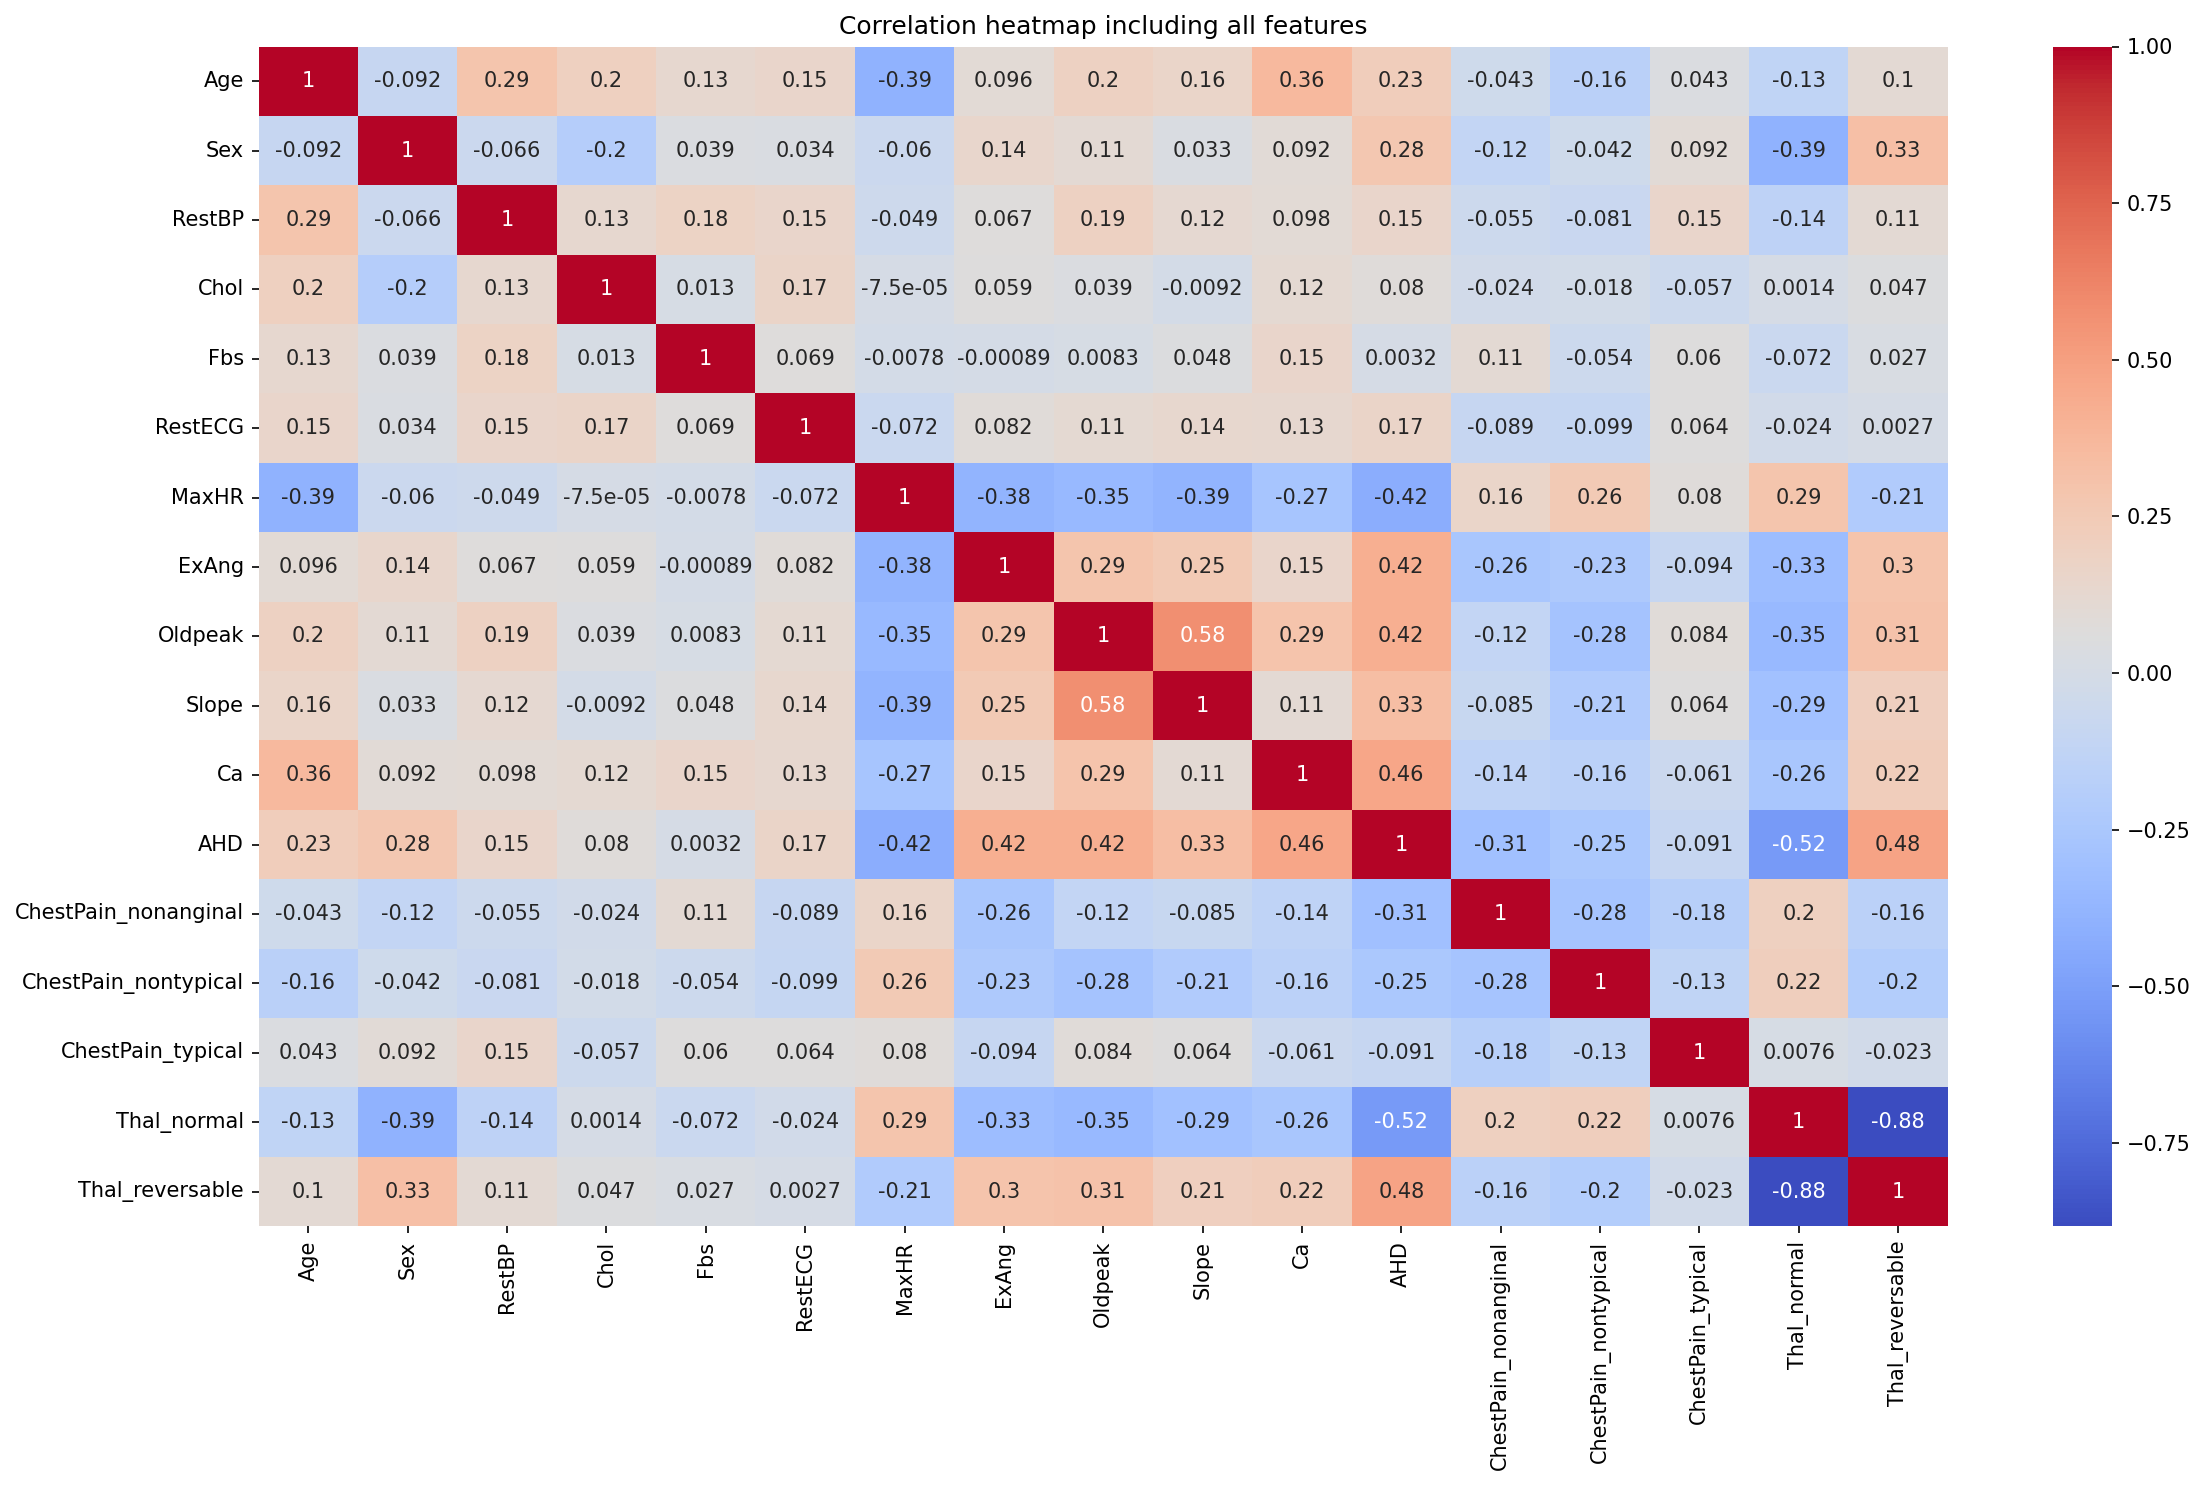

In [30]:
corr = df_dummy.corr()

plt.figure(figsize=(16, 10), dpi=150)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation heatmap including all features")
plt.tight_layout()
plt.show()

In [31]:
# print list of correlations desc
# conclusions: Thal_revers, Ca, ExAng, OldPeak are high correlations to AHD 
# ie these are predictive signals that show association

corr_AHD = corr["AHD"].sort_values(ascending=False)
print(corr_AHD)

AHD                     1.000000
Thal_reversable         0.484657
Ca                      0.463189
Oldpeak                 0.424052
ExAng                   0.421355
Slope                   0.333049
Sex                     0.278467
Age                     0.227075
RestECG                 0.166343
RestBP                  0.153490
Chol                    0.080285
Fbs                     0.003167
ChestPain_typical      -0.091208
ChestPain_nontypical   -0.247535
ChestPain_nonanginal   -0.305345
MaxHR                  -0.423817
Thal_normal            -0.524972
Name: AHD, dtype: float64


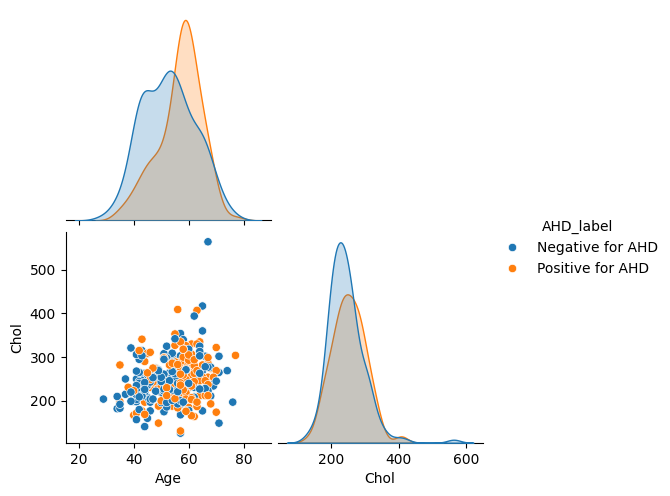

In [38]:
# check clusters of certain combinations:
# age vs col coloured by AHD
df["AHD_label"] = df["AHD"].map({0: "Negative for AHD", 1: "Positive for AHD"})
sns.pairplot(
    data = df[["Age", "Chol", "AHD_label"]],
    corner= True,
    hue= "AHD_label",
    palette="tab10"
)

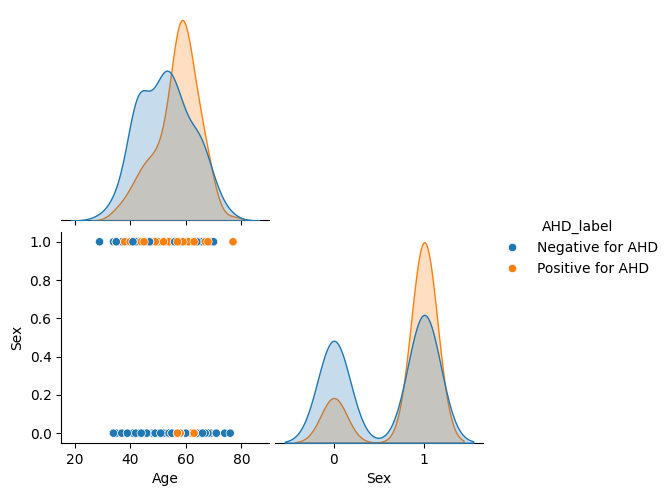

In [39]:
# Age vs Sex -> AHD
#df["AHD"] = df["AHD"].map({0: "LOW correlation", 1: "HIGH correlation"})
df["AHD_label"] = df["AHD"].map({0: "Negative for AHD", 1: "Positive for AHD"})
sns.pairplot(
    data = df[["Age", "Sex", "AHD_label"]],
    corner= True,
    hue= "AHD_label",
    palette="tab10"
)

# gender/sex Female= 0, Male= 1 (source: Kaggle)

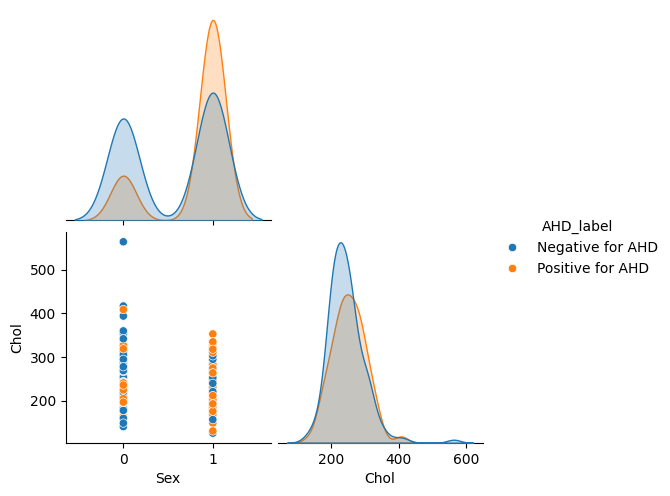

In [40]:
# Chol vs Sex -> AHD
# Gender/Sex 0=Female, 1=Male
df["AHD_label"] = df["AHD"].map({0: "Negative for AHD", 1: "Positive for AHD"})
sns.pairplot(
    data = df[["Sex", "Chol", "AHD_label"]],
    corner= True,
    hue= "AHD_label",
    palette="tab10"
)

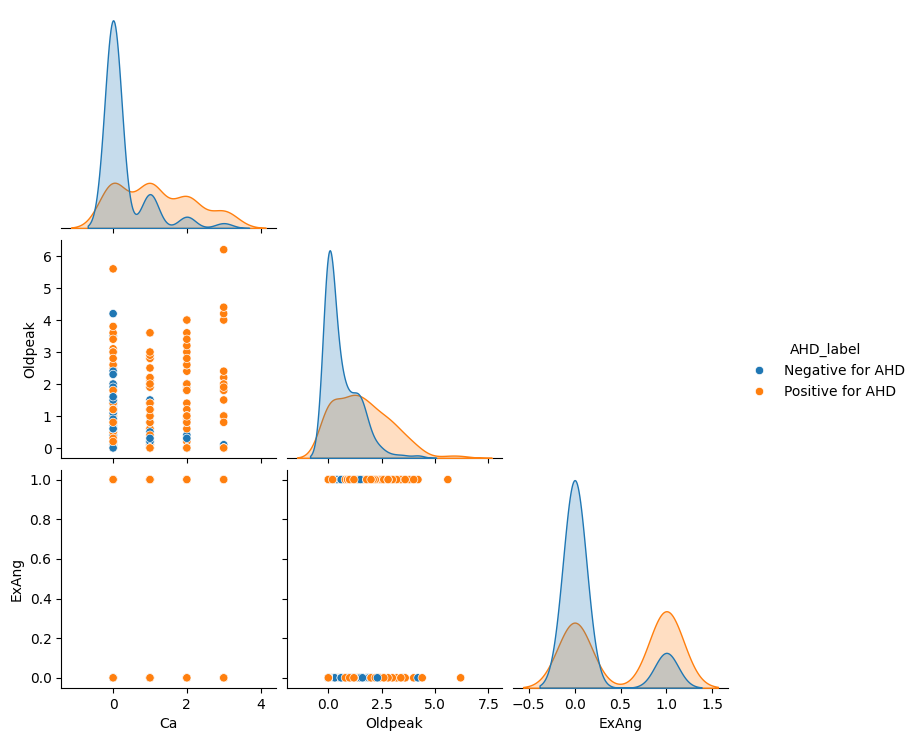

In [42]:
# Finally top 3 (4) pairplots set to show highest correlations
#Thal_reversable         0.484657
# Ca                      0.463189
# Oldpeak                 0.424052
# ExAng 

df["AHD_label"] = df["AHD"].map({0: "Negative for AHD", 1: "Positive for AHD"})
sns.pairplot(
    data = df[["Thal", "Ca", "Oldpeak", "ExAng", "AHD_label"]],
    corner= True,
    hue= "AHD_label",
    palette="tab10"
)

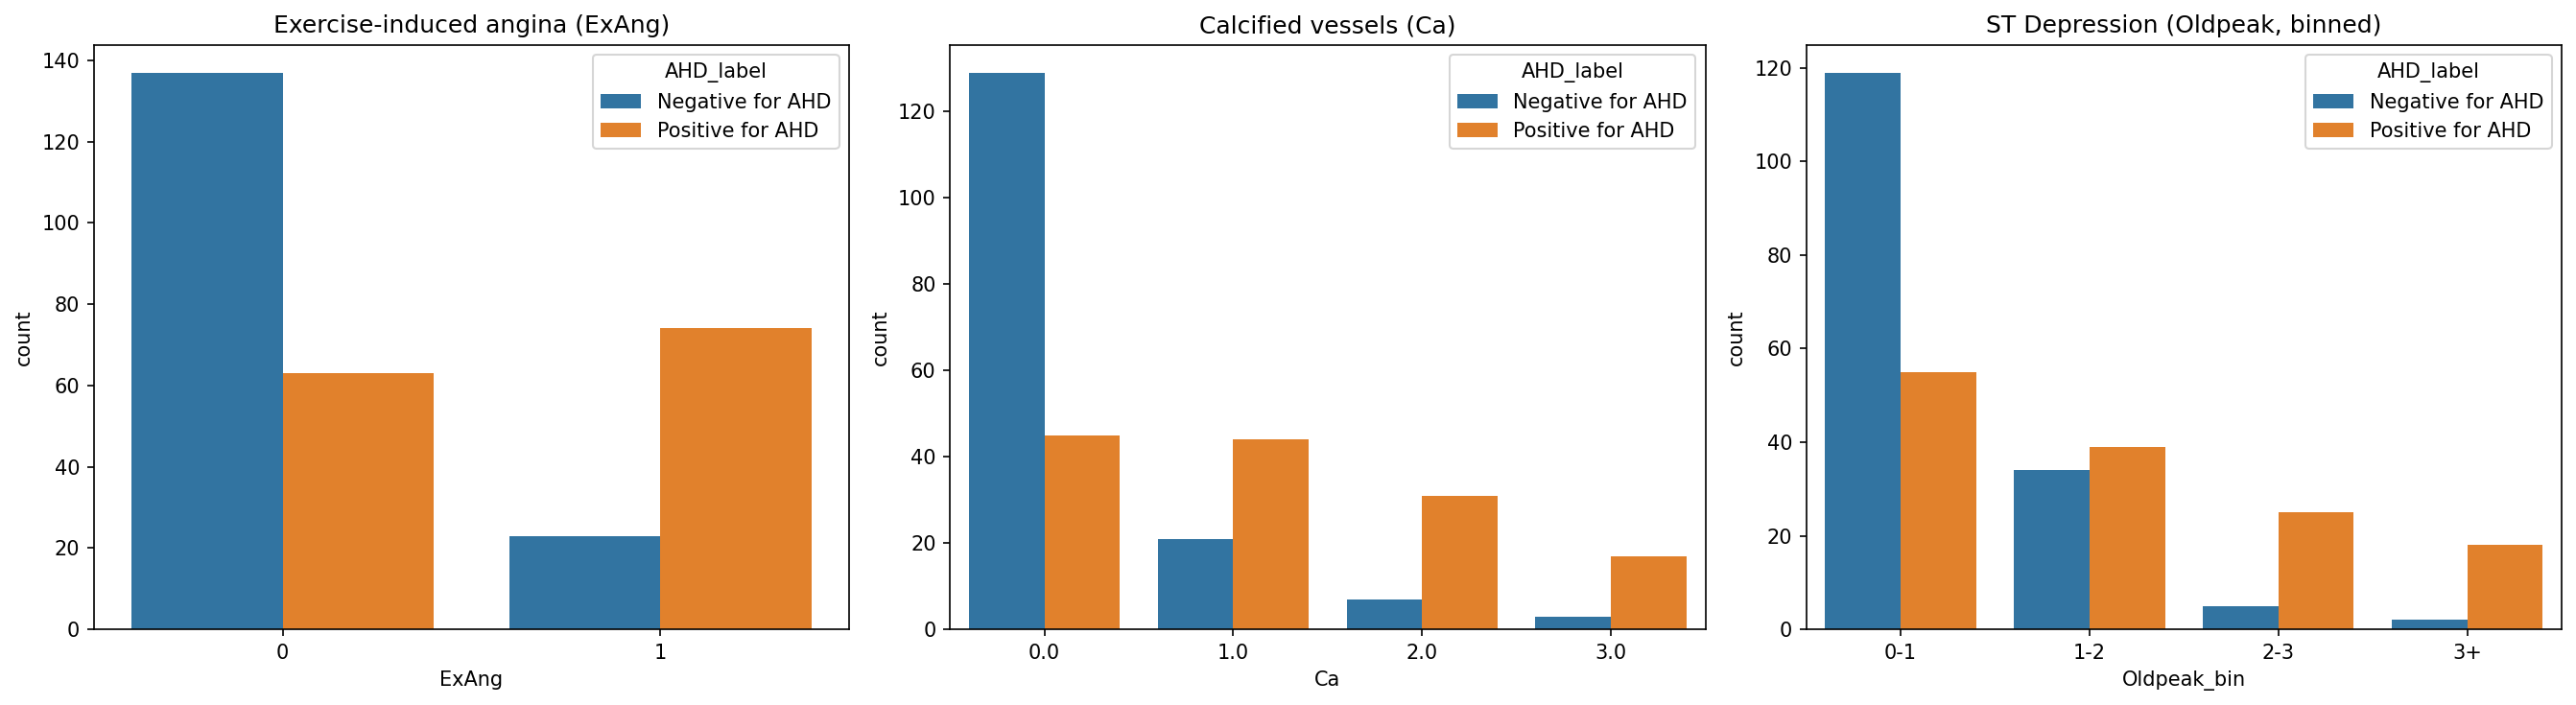

In [49]:
# to summarize, barchart to visualise correlations

fig, axes = plt.subplots(1, 3, figsize=(18,5), dpi=150)

# 1. ExAng vs AHD
sns.countplot(x="ExAng", hue="AHD_label", data=df, ax=axes[0])
axes[0].set_title("Exercise-induced angina (ExAng)")

# 2. Ca vs AHD
sns.countplot(x="Ca", hue="AHD_label", data=df, ax=axes[1])
axes[1].set_title("Calcified vessels (Ca)")

# 3. Oldpeak (binned) vs AHD
# Turn Oldpeak (continuous) into categories for a bar chart
df["Oldpeak_bin"] = pd.cut(df["Oldpeak"], bins=[-0.1,1,2,3,7], labels=["0-1","1-2","2-3","3+"])
sns.countplot(x="Oldpeak_bin", hue="AHD_label", data=df, ax=axes[2])
axes[2].set_title("ST Depression (Oldpeak, binned)")

plt.tight_layout()
plt.show()


## Random Forest Classifier 

In [58]:
df_dummies = pd.get_dummies(df, drop_first=True)
df_dummies.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False,False


In [60]:
from sklearn.model_selection import train_test_split

X, y = df_dummies.drop("AHD_Yes", axis=1), df_dummies["AHD_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((237, 16), (60, 16))

In [61]:
X_train.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
278,39,0,138,220,0,0,152,0,0.0,2,0.0,True,False,False,True,False
263,60,0,150,240,0,0,171,0,0.9,1,0.0,False,False,True,True,False
31,69,0,140,239,0,0,151,0,1.8,1,2.0,False,False,True,True,False
23,58,1,120,284,0,2,160,0,1.8,2,0.0,False,True,False,True,False
282,47,1,130,253,0,0,179,0,0.0,1,0.0,True,False,False,True,False


In [62]:
y_train.head()

278    False
263    False
31     False
23      True
282    False
Name: AHD_Yes, dtype: bool

In [65]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
y_pred

array([False,  True, False,  True, False, False, False,  True,  True,
       False, False, False, False,  True, False, False, False, False,
        True, False,  True,  True,  True, False,  True, False,  True,
        True, False, False, False, False,  True, False, False, False,
        True, False,  True,  True, False,  True,  True,  True, False,
        True, False,  True, False, False, False,  True, False, False,
        True,  True, False, False,  True,  True])

## Evaluation

              precision    recall  f1-score   support

       False       0.94      0.89      0.91        36
        True       0.85      0.92      0.88        24

    accuracy                           0.90        60
   macro avg       0.89      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



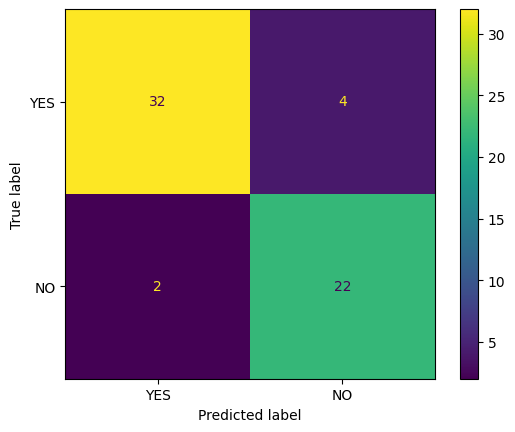

In [72]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_classification (y_test, y_pred, labels= ["YES", "NO"]):
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot()

evaluate_classification(y_test, y_pred)

In [73]:
model_rf.feature_importances_

array([0.08839598, 0.03404896, 0.08362822, 0.09486928, 0.01300379,
       0.02115667, 0.12223509, 0.05525256, 0.11696637, 0.03096116,
       0.14055381, 0.03680003, 0.00910466, 0.01581684, 0.07399679,
       0.06320981])

In [75]:
model_rf.feature_importances_.shape, X_train.shape

((16,), (237, 16))

In [76]:
model_rf.feature_importances_.sum()

np.float64(0.9999999999999999)

In [81]:
# have a look into feature importance. transpose columns
feature_importance = pd.DataFrame([X.columns, model_rf.feature_importances_]).T
feature_importance.columns = ["Feature", "Importance"]
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
10,Ca,0.140554
6,MaxHR,0.122235
8,Oldpeak,0.116966
3,Chol,0.094869
0,Age,0.088396
2,RestBP,0.083628
14,Thal_normal,0.073997
15,Thal_reversable,0.06321
7,ExAng,0.055253
11,ChestPain_nonanginal,0.0368


<Axes: xlabel='Importance', ylabel='Feature'>

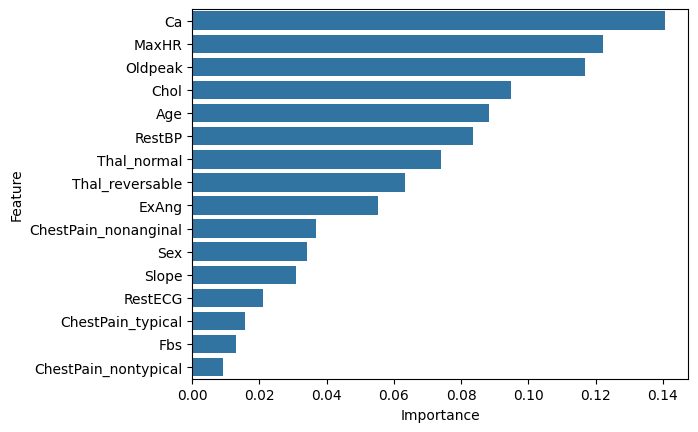

In [80]:
# plot to visualise feature importance for AHD
sns.barplot(data=feature_importance, x="Importance", y="Feature")